# 04 Statistical Analysis & Modeling

**Purpose:** Apply rigorous statistical tests to validate business hypotheses and build predictive models to understand revenue drivers.

**Statistical Methods Used:**
1. **Normality Testing (Shapiro-Wilk):** Assess the distribution of order values.
2. **Mann-Whitney U Test:** A robust non-parametric test to compare order values (discount vs. no discount).
3. **ANOVA (Analysis of Variance):** Determine if product categories significantly affect order values.
4. **Chi-Squared Test of Independence:** Check if discount usage is dependent on the sales channel.
5. **OLS Multiple Linear Regression:** Explain the variance in `total_spent` using multiple predictors.
6. **Time Series Forecasting:** Forecast future revenue using trend analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_dataset.csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (11971, 19)


### Step 1: Normality Testing (Shapiro-Wilk Test)
**Why:** Before applying parametric tests like the T-test or ANOVA, we must check if our primary continuous variable (`total_spent`) follows a normal distribution. Since the dataset is large, we'll sample 5,000 records for the Shapiro-Wilk test.

In [2]:
sample_data = df['total_spent'].sample(n=min(5000, len(df)), random_state=42)
stat, p_value = stats.shapiro(sample_data)

print("=== Shapiro-Wilk Normality Test ===")
print(f"Test Statistic: {stat:.4f}")
print(f"P-Value: {p_value:.10f}")

if p_value < 0.05:
    print("\nConclusion: Data is NOT normally distributed (p < 0.05). Non-parametric tests are recommended.")
else:
    print("\nConclusion: Data appears normally distributed.")

=== Shapiro-Wilk Normality Test ===
Test Statistic: 0.9231
P-Value: 0.0000000000

Conclusion: Data is NOT normally distributed (p < 0.05). Non-parametric tests are recommended.


### Step 2: Non-Parametric Hypothesis Testing (Mann-Whitney U Test)
**Question:** Does applying a discount significantly change the order value?

**Why:** Because `total_spent` is not normally distributed, Welch's T-test can be less reliable. The Mann-Whitney U test compares the median distributions of discounted vs. non-discounted transactions.

In [3]:
discounted = df[df['discount_applied'] == 1]['total_spent']
no_discount = df[df['discount_applied'] == 0]['total_spent']

u_stat, p_value = stats.mannwhitneyu(discounted, no_discount, alternative='two-sided')

print("=== Mann-Whitney U Test: Discount vs No Discount ===")
print(f"Discounted Median   : ${discounted.median():.2f}")
print(f"No Discount Median  : ${no_discount.median():.2f}")
print(f"U-Statistic         : {u_stat:.4f}")
print(f"P-Value             : {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: REJECT the null hypothesis. The distributions of order values are significantly different.")
else:
    print("\nConclusion: FAIL TO REJECT the null hypothesis. There is no significant difference.")

=== Mann-Whitney U Test: Discount vs No Discount ===
Discounted Median   : $109.50
No Discount Median  : $108.50
U-Statistic         : 16063205.0000
P-Value             : 0.639406

Conclusion: FAIL TO REJECT the null hypothesis. There is no significant difference.


### Step 3: Analysis of Variance (One-Way ANOVA)
**Question:** Does the product category significantly affect the average order value?

**Why:** We want to know if revenue differences between categories are statistically significant or just random variation. *(Note: While ANOVA assumes normality, it is highly robust to violations with large sample sizes like ours).* 

In [4]:
# Create a list of arrays for each category's total_spent
category_groups = [group['total_spent'].values for name, group in df.groupby('category')]

f_stat, p_value = stats.f_oneway(*category_groups)

print("=== One-Way ANOVA: Total Spent Across Categories ===")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value    : {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: REJECT the null hypothesis. At least one category has a significantly different average order value.")
else:
    print("\nConclusion: FAIL TO REJECT. Category does not significantly impact order values.")

=== One-Way ANOVA: Total Spent Across Categories ===
F-Statistic: 5.8244
P-Value    : 0.000001

Conclusion: REJECT the null hypothesis. At least one category has a significantly different average order value.


### Step 4: Chi-Squared Test of Independence
**Question:** Is discount usage independent of the sales location (Online vs. In-Store)?

**Why:** To determine if the business is disproportionately giving discounts to online shoppers compared to in-store shoppers.

In [5]:
contingency_table = pd.crosstab(df['discount_applied'], df['location'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("=== Chi-Squared Test: Discount Applied vs Location ===")
print("Observed Frequencies:\n", contingency_table)
print(f"\nChi-Squared Stat: {chi2:.4f}")
print(f"P-Value         : {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: DEPENDENT. Discount application differs significantly between Online and In-Store channels.")
else:
    print("\nConclusion: INDEPENDENT. Discounts are evenly distributed across both channels.")

=== Chi-Squared Test: Discount Applied vs Location ===
Observed Frequencies:
 location          In-Store  Online
discount_applied                  
0                     3941    4011
1                     1962    2057

Chi-Squared Stat: 0.5583
P-Value         : 0.454928

Conclusion: INDEPENDENT. Discounts are evenly distributed across both channels.


### Step 5: OLS Multiple Linear Regression (Statsmodels)
**Why:** We want to explain the variance in `total_spent`. We will model `total_spent` based on `quantity`, `discount_applied`, and dummy variables for `location`. `statsmodels` provides a comprehensive statistical summary (p-values for coefficients, R-squared).

In [6]:
# Prepare features: quantity, discount_applied, and location (dummy encoded)
X_features = df[['quantity', 'discount_applied']].copy()
X_features['is_online'] = (df['location'] == 'Online').astype(int)

# Add a constant for the intercept
X_ols = sm.add_constant(X_features)
y_ols = df['total_spent']

# Fit the Ordinary Least Squares (OLS) model
ols_model = sm.OLS(y_ols, X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_spent   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     4104.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:44:15   Log-Likelihood:                -67234.
No. Observations:               11971   AIC:                         1.345e+05
Df Residuals:                   11967   BIC:                         1.345e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -1.7466      1.520  

**Statistical Insight:** The OLS summary above details exactly how much each feature contributes to `total_spent`. Look at the `P>|t|` column to see which features are statistically significant predictors (values < 0.05).

### Step 6: Time Series Forecasting (Machine Learning)
**Why:** We will model historical monthly revenue and forecast performance for the next 6 months to aid financial planning.

Forecasting Model R² Score: 0.0166


/Users/anshkumar/Desktop/DVA-Private/some/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


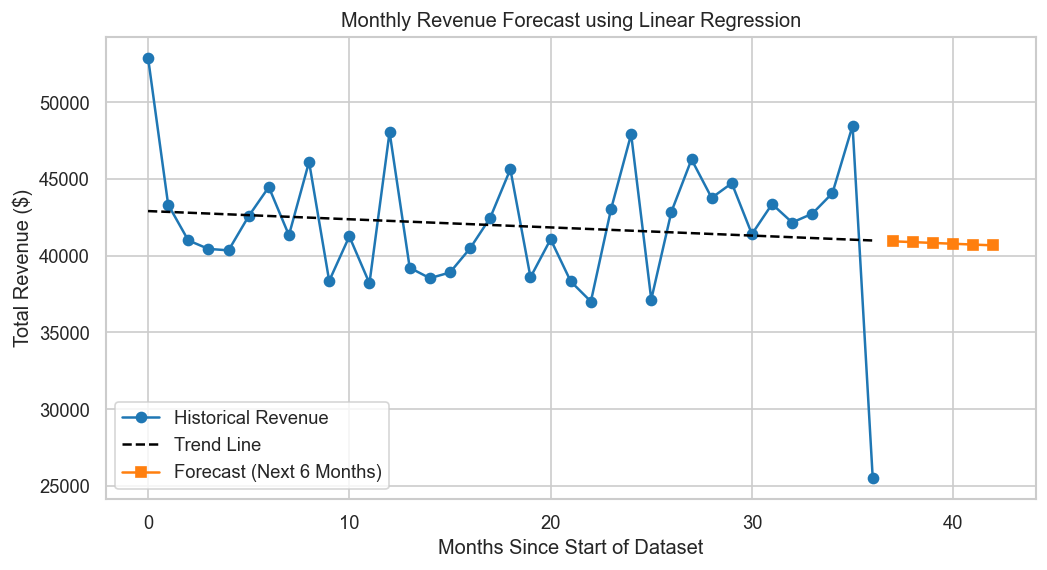

In [7]:
# Aggregate revenue by month
monthly_rev = df.groupby(['transaction_year', 'transaction_month'])['total_spent'].sum().reset_index()
monthly_rev = monthly_rev.sort_values(['transaction_year', 'transaction_month']).reset_index(drop=True)

# Create an ordinal time index (0, 1, 2... N)
monthly_rev['time_index'] = monthly_rev.index

# Fit Linear Regression Model
X = monthly_rev[['time_index']]
y = monthly_rev['total_spent']
model = LinearRegression()
model.fit(X, y)

# Forecast next 6 months
future_indices = np.array(range(len(monthly_rev), len(monthly_rev) + 6)).reshape(-1, 1)
forecast_values = model.predict(future_indices)

print("Forecasting Model R² Score:", round(model.score(X, y), 4))

# Visualize Historical + Forecasted Revenue
plt.figure(figsize=(10, 5))
plt.plot(monthly_rev['time_index'], y, marker='o', label='Historical Revenue', color='#1f77b4')
plt.plot(monthly_rev['time_index'], model.predict(X), color='black', linestyle='--', label='Trend Line')
plt.plot(future_indices, forecast_values, marker='s', color='#ff7f0e', label='Forecast (Next 6 Months)')
plt.title('Monthly Revenue Forecast using Linear Regression')
plt.xlabel('Months Since Start of Dataset')
plt.ylabel('Total Revenue ($)')
plt.legend()
plt.show()

### Step 7: Final Business KPIs
**Why:** Extracting the exact top-level metrics needed for the executive Tableau dashboard summary.

In [8]:
total_revenue = df['total_spent'].sum()
aov = df['total_spent'].mean()
discount_rate = (df['discount_applied'].sum() / len(df)) * 100
online_pct = (len(df[df['location'] == 'Online']) / len(df)) * 100
instore_pct = (len(df[df['location'] == 'In-Store']) / len(df)) * 100

print("="*40)
print("         FINAL BUSINESS KPIs")
print("="*40)
print(f"Total Revenue    : ${total_revenue:,.2f}")
print(f"Average Order Vol: ${aov:,.2f}")
print(f"Discount Rate    : {discount_rate:.2f}%")
print(f"Online Sales     : {online_pct:.2f}%")
print(f"In-Store Sales   : {instore_pct:.2f}%")
print("="*40)

         FINAL BUSINESS KPIs
Total Revenue    : $1,552,071.00
Average Order Vol: $129.65
Discount Rate    : 33.57%
Online Sales     : 50.69%
In-Store Sales   : 49.31%
